<a href="https://colab.research.google.com/github/tanzeelaalvi717-blip/Protein-structure-prediction/blob/main/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# @title 1) Check the runtime
import sys, platform, os, textwrap
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("Working dir:", os.getcwd())

!arch

Python: 3.12.13
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Working dir: /content
x86_64


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# @title Create directories `~/Project Files/data` and `~/Project Files/outputs`

import os
from pathlib import Path

# Change this folder name once; everything else uses it.
COURSE_DIR_NAME = "Project Files"  # you can rename for your course

USE_DRIVE = True

if "drive" in str(Path("/content/drive")) and os.path.exists("/content/drive") and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive") / COURSE_DIR_NAME
else:
    ROOT = Path("/content") / COURSE_DIR_NAME

ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
(DATA_DIR).mkdir(exist_ok=True)

OUTPUTS_DIR = ROOT / "outputs"
(OUTPUTS_DIR).mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("Use Path object DATA_DIR to access:", DATA_DIR)
print("Use Path object OUTPUTS_DIR to access:", OUTPUTS_DIR)

ROOT: /content/drive/MyDrive/Project Files
Use Path object DATA_DIR to access: /content/drive/MyDrive/Project Files/data
Use Path object OUTPUTS_DIR to access: /content/drive/MyDrive/Project Files/outputs


In [4]:
# @title Download the vina executable

!wget https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.3/vina_1.2.3_linux_x86_64
!mv vina_1.2.3_linux_x86_64 vina #rename the vina_1.2.3_linux_x86_64 as vina
!chmod +x vina

--2026-04-27 04:15:15--  https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.3/vina_1.2.3_linux_x86_64
Resolving github.com (github.com)... 20.27.177.113
Connecting to github.com (github.com)|20.27.177.113|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/258054635/ae531efa-011f-44eb-86d3-dc1115228edc?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-04-27T04%3A48%3A39Z&rscd=attachment%3B+filename%3Dvina_1.2.3_linux_x86_64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-04-27T03%3A48%3A17Z&ske=2026-04-27T04%3A48%3A39Z&sks=b&skv=2018-11-09&sig=fqqCChU5SRtjhZYwbDYR3cDU36LBk5Adz09qL25ZOsE%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3NzI2MzU3OCwibmJmIjoxNzc3MjYzMjc4LCJwYXRoIjoicmVsZWFzZ

In [5]:
!/usr/local/bin/pip --help


Usage:   
  pip3 <command> [options]

Commands:
  install                     Install packages.
  download                    Download packages.
  uninstall                   Uninstall packages.
  freeze                      Output installed packages in requirements format.
  inspect                     Inspect the python environment.
  list                        List installed packages.
  show                        Show information about installed packages.
  check                       Verify installed packages have compatible dependencies.
  config                      Manage local and global configuration.
  search                      Search PyPI for packages.
  cache                       Inspect and manage pip's wheel cache.
  index                       Inspect information available from package indexes.
  wheel                       Build wheels from your requirements.
  hash                        Compute hashes of package archives.
  completion                  A helper c

After `condacolab` installation and kernel restart, the Python environment and paths are updated. The previous `pip` executable might not be correctly linked. Let's check the new path for `pip` and its version.

In [6]:
print('Checking pip path:')
!which pip

print('\nChecking pip version:')
!pip --version

Checking pip path:
/usr/local/bin/pip

Checking pip version:
pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)


In [8]:
!/usr/local/bin/python -m conda install pip --yes

Channels:
 - conda-forge
Platform: linux-64
/ done
Solving environment: \ | / done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - pip


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    certifi-2026.4.22          |     pyhd8ed1ab_0         132 KB  conda-forge
    conda-24.11.3              |  py311h38be061_0         1.1 MB  conda-forge
    openssl-3.6.2              |       h35e630c_0         3.0 MB  conda-forge
    pip-26.0.1                 |     pyh8b19718_0         1.1 MB  conda-forge
    ------------------------------------------------------------
                                           Total:         5.5 MB

The following packages will be UPDATED:

  ca-certificates    conda-forge/linux-64::ca-certificates~ --> conda-forge/noarch::ca-certificates-2026.4.

In [7]:
!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:12
🔁 Restarting kernel...


In [1]:
# @title Let's inspect the new conda info
!conda info


     active environment : None
       user config file : /root/.condarc
 populated config files : /usr/local/.condarc
          conda version : 24.11.3
    conda-build version : not installed
         python version : 3.11.11.final.0
                 solver : libmamba (default)
       virtual packages : __archspec=1=broadwell
                          __conda=24.11.3=0
                          __glibc=2.35=0
                          __linux=6.6.113=0
                          __unix=0=0
       base environment : /usr/local  (writable)
      conda av data dir : /usr/local/etc/conda
  conda av metadata url : None
           channel URLs : https://conda.anaconda.org/conda-forge/linux-64
                          https://conda.anaconda.org/conda-forge/noarch
          package cache : /usr/local/pkgs
                          /root/.conda/pkgs
       envs directories : /usr/local/envs
                          /root/.conda/envs
               platform : linux-64
             user-agent :

In [2]:
# @title Install Python packages (~1 min)
!conda install -c conda-forge -c bioconda mgltools openbabel zlib --yes

Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: | / - done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.3
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - mgltools
    - openbabel
    - zlib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    cairo-1.18.4               |       h3394656_0         955 KB  conda-forge
    font-ttf-dejavu-sans-mono-2.37|       hab24e00_0         388 KB  conda-forge
    font-ttf-inconsolata-3.000 |       h77eed37_0          94 KB  conda-forge
    font-ttf-source-code-pro-2.038|       h77eed37_0         684 KB  conda-forge
    font-ttf-ubuntu-0.83       |       h77eed37_3         1.5 MB  conda-forge
    fontconfig-2.15.0          |       h7e30c49_1

In [3]:
# Reinstall pip to fix the ImportError
!curl https://bootstrap.pypa.io/get-pip.py -o get-pip.py
!python3 get-pip.py --force-reinstall

# Install Biopython using pip
!pip install -q biopython

curl: /usr/local/lib/libcurl.so.4: no version information available (required by curl)
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2142k  100 2142k    0     0  14.1M      0 --:--:-- --:--:-- --:--:-- 14.1M
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 9.9 MB/s  0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 26.0.1
    Uninstalling pip-26.0.1:
      Successfully uninstalled pip-26.0.1


In [4]:
# @title Verify that mgltools has been installed

import shutil

# Find the pathname of prepare_receptor4.py
receptor_prep_script = shutil.which('prepare_receptor4.py')
print(f'Path to prepare_receptor4.py: {receptor_prep_script}')

# Find the pathname of prepare_ligand4.py
ligand_prep_script = shutil.which('prepare_ligand4.py')
print(f'Path to prepare_ligand4.py: {ligand_prep_script}')

# Check if python2 is available
python2_path = shutil.which('python2')
print(f'Path to python2: {python2_path}')

#@markdown > You should see that the executables `prepare_receptor4.py` and `prepare_ligand4.py` are available in your path
#@markdown >
#@markdown > You should also have Python2 (!) available to run these scripts

Path to prepare_receptor4.py: /usr/local/bin/prepare_receptor4.py
Path to prepare_ligand4.py: /usr/local/bin/prepare_ligand4.py
Path to python2: /usr/local/bin/python2


In [5]:
# @title Reinstantiate Path objects and create INPUT_FILES = DATA_DIR /input_files`

import os
from pathlib import Path

# Change this folder name once; everything else uses it.
COURSE_DIR_NAME = "Project Files"  # you can rename for your course

USE_DRIVE = True

if "drive" in str(Path("/content/drive")) and os.path.exists("/content/drive") and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive") / COURSE_DIR_NAME
else:
    ROOT = Path("/content") / COURSE_DIR_NAME

ROOT.mkdir(parents=True, exist_ok=True)

DATA_DIR = ROOT / "data"
(DATA_DIR).mkdir(exist_ok=True)

OUTPUTS_DIR = ROOT / "outputs"
(OUTPUTS_DIR).mkdir(exist_ok=True)

INPUT_FILES = DATA_DIR / "input_files"

print("ROOT:", ROOT)
print("Use Path object DATA_DIR to access:", DATA_DIR)
print("Use Path object OUTPUTS_DIR to access:", OUTPUTS_DIR)
print()
print("Use Path object INPUT_FILES to access:", INPUT_FILES)

ROOT: /content/drive/MyDrive/Project Files
Use Path object DATA_DIR to access: /content/drive/MyDrive/Project Files/data
Use Path object OUTPUTS_DIR to access: /content/drive/MyDrive/Project Files/outputs

Use Path object INPUT_FILES to access: /content/drive/MyDrive/Project Files/data/input_files


In [6]:
self_pairs = {
    ('4DKO', 'TS-II-224'): '0LM',
    ('4DKR', 'AWS-I-169'): '0LJ',
    ('4DKU', 'NBD-09027'): '0KU',
    ('4DKV', 'NBD-10007'): '0KW',
    ('4RZ8', 'NBD-11021'): '3ZM',
}

# **Preparation of receptors and ligands for docking**
# **Receptors**
Here, we will use the mgltools to prepare PDBQT files for all five gp120 HIV-1 receptors:

4DKO_receptor_prepped.pdb  - gp120 structure from TS-II-224 complex  
4DKR_receptor_prepped.pdb  - gp120 structure from AWS-I-169 complex  
4DKU_receptor_prepped.pdb  - gp120 structure from NBD-09027 complex  
4DKV_receptor_prepped.pdb  - gp120 structure from NBD-10007 complex  
4RZ8_receptor_prepped.pdb  - gp120 structure from NBD-11021 complex

## **Inhibitors**
# We will also prepare PDBQT files for five gp120 inhibitors:

| Ligand    | PDB ID | SMILES                                                                                 | Approx IC50 (µM) |
| --------- | ------ | -------------------------------------------------------------------------------------- | ---------------- |
| TS-II-224 | 4DKO   | CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)Cl)F)C                                    | ~1.0             |
| AWS-I-169 | 4DKR   | C1C(C(C2=CC=CC=C21)NC(=O)C(=O)NC3=CC(=C(C=C3)Cl)F)N=C(N)N | ~2.0             |
| NBD-09027 | 4DKU   | CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=C3)Cl)CO                                           | ~0.5             |
| NBD-10007 | 4DKV   | CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=C3)Cl)CCO                      | ~0.2             |
| NBD-11021 | 4RZ8   | CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C3=CC=C(N3)C4=CC=C(C=C4)Cl)CO                            | ~0.1             |


In [20]:
import os
import subprocess
import pandas as pd
from pathlib import Path

# Create ligand table for your gp120 project
gp120_ligands = [
    {
        "ligand": "TS-II-224",
        "PDB": "4DKO",
        "SMILES": "CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)Cl)F)C"
    },
    {
        "ligand": "AWS-I-169",
        "PDB": "4DKR",
        "SMILES": "C1[C@H]([C@@H](C2=CC=CC=C21)NC(=O)C(=O)NC3=CC(=C(C=C3)Cl)F)N=C(N)N"
    },
    {
        "ligand": "NBD-09027",
        "PDB": "4DKU",
        "SMILES": "CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=C3)Cl)CO" # Corrected SMILES
    },
    {
        "ligand": "NBD-10007",
        "PDB": "4DKV",
        "SMILES": "CC1=C(SC(=N1)[C@H]([C@@H]2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=C3)Cl)CCO"
    },
    {
        "ligand": "NBD-11021",
        "PDB": "4RZ8",
        "SMILES": "CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C3=CC=C(N3)C4=CC=C(C=C4)Cl)CO"
    }
]

df = pd.DataFrame(gp120_ligands)

# Save CSV for record keeping
df.to_csv(INPUT_FILES / "gp120_binders.csv", index=False)
print(f"✅ Saved: {INPUT_FILES / 'gp120_binders.csv'}")


def run_cmd(cmd):
    print(">>", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    return result


# Create ligand folders and prepare each ligand
for index, row in df.iterrows():

    ligand = row["ligand"].strip() # Strip whitespace from ligand name
    smiles = row["SMILES"].strip() # Strip whitespace from SMILES string

    print(f"\nProcessing ligand: {ligand}")
    print(f"SMILES: {smiles}")

    ligdir = INPUT_FILES / ligand
    ligdir.mkdir(exist_ok=True)

    # Write SMILES file
    smilesfile = ligdir / f"{ligand}.smiles"
    with open(smilesfile, "w") as fout:
        fout.write(smiles)

    print(f"✅ Wrote: {smilesfile}")

    # Convert SMILES to 3D MOL2 with OpenBabel
    mol2file = ligdir / f"{ligand}.mol2"

    run_cmd([
        "obabel",
        str(smilesfile),
        "-O", str(mol2file),
        "--gen3d",
        "--best",
        "--canonical",
        "--conformers",
        "--weighted",
        "--nconf", "50",
        "--ff", "GAFF"
    ])

    if not mol2file.exists():
        print(f"❌ Failed to create MOL2: {mol2file}")
        continue

    print(f"✅ Created MOL2: {mol2file}")

    # Prepare ligand PDBQT using AutoDockTools
    pdbqtfile = ligdir / f"{ligand}.pdbqt"

    local_mol2file_name = f"{ligand}.mol2"
    local_pdbqtfile_name = f"{ligand}.pdbqt"

    # Copy the mol2 file to current directory for prepare_ligand4.py
    run_cmd(["cp", str(mol2file), local_mol2file_name])

    run_cmd(
        [
            python2_path,
            ligand_prep_script,
            "-l",
            local_mol2file_name,  # Use local file
            "-o",
            local_pdbqtfile_name,  # Output to local file
            "-U",
            "nphs_lps",
            "-v",
        ]
    )

    # Move the generated pdbqt file back to its target directory
    run_cmd(["mv", local_pdbqtfile_name, str(pdbqtfile)])

    # Clean up the local mol2 file
    run_cmd(["rm", local_mol2file_name])

    if pdbqtfile.exists():
        print(f"✅ Created PDBQT: {pdbqtfile}")
    else:
        print(f"❌ Failed to create PDBQT: {pdbqtfile}")

✅ Saved: /content/drive/MyDrive/Project Files/data/input_files/gp120_binders.csv

Processing ligand: TS-II-224
SMILES: CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)Cl)F)C
✅ Wrote: /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.smiles
>> obabel /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.smiles -O /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.mol2 --gen3d --best --canonical --conformers --weighted --nconf 50 --ff GAFF
1 molecule converted

✅ Created MOL2: /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.mol2
>> cp /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/TS-II-224.mol2 TS-II-224.mol2
>> /usr/local/bin/python2 /usr/local/bin/prepare_ligand4.py -l TS-II-224.mol2 -o TS-II-224.pdbqt -U nphs_lps -v
set verbose to  True
read  TS-II-224.mol2
setting up LPO with mode= automatic and outputfilename=  TS-II-224.pdbqt
and check_for_fragments= False
and bonds_to_inacti

In [21]:
print(f"Listing contents of: {INPUT_FILES}")
!ls -l "{INPUT_FILES}"

# Also explicitly check for the receptor PDBQT files
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']
print("\nChecking for receptor_XXXX.pdbqt files:")
for rec_code in receptor_codes:
    receptor_pdbqt_path = INPUT_FILES / f'receptor_{rec_code}.pdbqt'
    if receptor_pdbqt_path.exists():
        print(f"✅ Found: {receptor_pdbqt_path}")
    else:
        print(f"❌ Missing: {receptor_pdbqt_path}")

Listing contents of: /content/drive/MyDrive/Project Files/data/input_files
total 15403
-rw-------  1 root root  718504 Apr 25 19:58 4DKO_chainA.pdb
-rw-------  1 root root 1010718 Apr 25 21:56 4DKO.pdb
-rw-------  1 root root  713241 Apr 24 23:23 4DKO_receptor_prepped.pdb
-rw-------  1 root root  720462 Apr 25 19:49 4DKR_chainA.pdb
-rw-------  1 root root 1017684 Apr 25 21:56 4DKR.pdb
-rw-------  1 root root  715807 Apr 24 23:34 4DKR_receptor_prepped.pdb
-rw-------  1 root root  715470 Apr 25 19:54 4DKU_chainA.pdb
-rw-------  1 root root  988200 Apr 25 21:56 4DKU.pdb
-rw-------  1 root root  710094 Apr 24 23:39 4DKU_receptor_prepped.pdb
-rw-------  1 root root  495806 Apr 25 19:55 4DKV_chainA.pdb
-rw-------  1 root root 1001646 Apr 25 21:56 4DKV.pdb
-rw-------  1 root root  715573 Apr 24 23:50 4DKV_receptor_prepped.pdb
-rw-------  1 root root  507583 Apr 25 19:56 4RZ8_chainA.pdb
-rw-------  1 root root 1995192 Apr 25 21:56 4RZ8.pdb
-rw-------  1 root root  724897 Apr 24 23:58 4RZ8_rece

In [22]:
# @title Prepare receptor PDBQT files

import os
import subprocess

receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Path to the prepare_receptor4.py script
receptor_prep_script = '/usr/local/bin/prepare_receptor4.py'
# Path to python2, which is required by prepare_receptor4.py
python2_path = '/usr/local/bin/python2'

for rec_code in receptor_codes:
    input_pdb_path = INPUT_FILES / f'{rec_code}.pdb'
    output_pdbqt_path = INPUT_FILES / f'receptor_{rec_code}.pdbqt'

    if not input_pdb_path.exists():
        print(f"❌ Input PDB file not found for {rec_code}: {input_pdb_path}")
        continue

    print(f"\nPreparing receptor: {rec_code}")

    # Ensure local copies for the script to work correctly
    local_pdb_name = f'{rec_code}.pdb'
    local_pdbqt_name = f'receptor_{rec_code}.pdbqt'

    # Copy input PDB to current directory
    subprocess.run(['cp', str(input_pdb_path), local_pdb_name], check=True)

    # Run prepare_receptor4.py
    cmd = [
        python2_path,
        receptor_prep_script,
        '-r', local_pdb_name, # Use local file
        '-o', local_pdbqt_name, # Output to local file
        '-U', 'nphs_lps',
        '-v'
    ]

    print(f">> {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    # Move generated PDBQT back to its target directory
    subprocess.run(['mv', local_pdbqt_name, str(output_pdbqt_path)], check=True)

    # Clean up local PDB file
    subprocess.run(['rm', local_pdb_name], check=True)

    if output_pdbqt_path.exists():
        print(f"✅ Created receptor PDBQT: {output_pdbqt_path}")
    else:
        print(f"❌ Failed to create receptor PDBQT: {output_pdbqt_path}")

print("\nAll receptor PDBQT preparation complete.")



Preparing receptor: 4DKO
>> /usr/local/bin/python2 /usr/local/bin/prepare_receptor4.py -r 4DKO.pdb -o receptor_4DKO.pdbqt -U nphs_lps -v
set verbose to  True
read  4DKO.pdb
setting up RPO with mode= automatic and outputfilename=  receptor_4DKO.pdbqt
charges_to_add= gasteiger
delete_single_nonstd_residues= None
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH601:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH602:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH603:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH604:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH605:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH606:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH607:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH608:O
Sorry, there are no Gasteiger parameters available for atom 4DKO:A:HOH609:O
Sor

In [23]:
import os
from pathlib import Path

# Ensure INPUT_FILES is defined (it should be from previous cells)
if 'INPUT_FILES' not in locals():
    print("INPUT_FILES not defined. Please ensure prior setup cells have run.")
    # Fallback or raise error if INPUT_FILES is critical and not found
    # For this example, we assume it's defined.

print(f"Extracting crystal ligand PDBs to {INPUT_FILES}...")

# Use the self_pairs dictionary to generate extraction commands
ligand_extraction_commands = []
for (rec_code, ligand_name), hetatm_code in self_pairs.items():
    cmd = f'grep "{hetatm_code}" "{{INPUT_FILES}}/{rec_code}.pdb" > "{{INPUT_FILES}}/{ligand_name}_ligand.pdb"'
    ligand_extraction_commands.append(cmd)

for cmd in ligand_extraction_commands:
    full_cmd = cmd.format(INPUT_FILES=INPUT_FILES)
    print(f">> {full_cmd}")
    os.system(full_cmd)

print("Crystal ligand PDB extraction complete.")

# Verify creation of files
expected_files = [
    INPUT_FILES / f"{ligand_name}_ligand.pdb" for (rec_code, ligand_name), hetatm_code in self_pairs.items()
]

for f in expected_files:
    if f.exists():
        print(f"✅ Created: {f}")
    else:
        print(f"❌ Failed to create: {f}")

Extracting crystal ligand PDBs to /content/drive/MyDrive/Project Files/data/input_files...
>> grep "0LM" "/content/drive/MyDrive/Project Files/data/input_files/4DKO.pdb" > "/content/drive/MyDrive/Project Files/data/input_files/TS-II-224_ligand.pdb"
>> grep "0LJ" "/content/drive/MyDrive/Project Files/data/input_files/4DKR.pdb" > "/content/drive/MyDrive/Project Files/data/input_files/AWS-I-169_ligand.pdb"
>> grep "0KU" "/content/drive/MyDrive/Project Files/data/input_files/4DKU.pdb" > "/content/drive/MyDrive/Project Files/data/input_files/NBD-09027_ligand.pdb"
>> grep "0KW" "/content/drive/MyDrive/Project Files/data/input_files/4DKV.pdb" > "/content/drive/MyDrive/Project Files/data/input_files/NBD-10007_ligand.pdb"
>> grep "3ZM" "/content/drive/MyDrive/Project Files/data/input_files/4RZ8.pdb" > "/content/drive/MyDrive/Project Files/data/input_files/NBD-11021_ligand.pdb"
Crystal ligand PDB extraction complete.
✅ Created: /content/drive/MyDrive/Project Files/data/input_files/TS-II-224_liga

In [24]:
# @title Dock all five gp120 ligands to all five gp120 receptors

import subprocess
from pathlib import Path
import pandas as pd

# gp120 receptors
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# gp120 ligand directories/files
# Dynamically create ligdirs from the DataFrame, preserving original names (which include leading spaces)
# Assumes df is available from previous cells
ligdirs = [str(name).strip() for name in df['ligand'].unique()]

# Load grid centers calculated from co-crystallized ligand centroids
grid_csv = INPUT_FILES / "gp120_grid_centers.csv"
centroid_df = pd.read_csv(grid_csv)

grid_params = {}
for _, row in centroid_df.iterrows():
    grid_params[row["PDB"]] = {
        "center": (row["center_x"], row["center_y"], row["center_z"]),
        "size": (row["size_x"], row["size_y"], row["size_z"])
    }

def run_cmd(cmd, log_file=None):
    print(">>", " ".join(cmd))
    if log_file:
        with open(log_file, "w") as lf:
            # When log_file is provided, redirect stdout/stderr to the file.
            # Do NOT use capture_output=True as it conflicts with explicit stdout/stderr.
            result = subprocess.run(cmd, text=True, stdout=lf, stderr=lf)
    else:
        # When no log_file, capture stdout/stderr to print later.
        result = subprocess.run(cmd, capture_output=True, text=True)

    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

    return result

for rec_code in receptor_codes:

    center_x, center_y, center_z = grid_params[rec_code]["center"]
    size_x, size_y, size_z = grid_params[rec_code]["size"]

    receptor_pdbqt = INPUT_FILES / f"receptor_{rec_code}.pdbqt"

    if not receptor_pdbqt.exists():
        print(f"❌ Missing receptor file: {receptor_pdbqt}")
        continue

    for ligand in ligdirs:

        LIG_DIR = INPUT_FILES / ligand
        ligand_pdbqt = LIG_DIR / f"{ligand}.pdbqt"
        config_file = LIG_DIR / f"config_dock_{rec_code}.txt"

        OUTFILE = OUTPUTS_DIR / f"docking_{rec_code}_{ligand}.pdbqt"
        LOGFILE = OUTPUTS_DIR / f"docking_{rec_code}_{ligand}.log"

        if not ligand_pdbqt.exists():
            print(f"❌ Missing ligand file: {ligand_pdbqt}")
            continue

        with open(config_file, "w") as f:
            f.write(f"""# CONFIGURATION FILE

# INPUT OPTIONS
receptor = {receptor_pdbqt}
ligand = {ligand_pdbqt}

# SEARCH SPACE CONFIGURATION
center_x = {center_x}
center_y = {center_y}
center_z = {center_z}

size_x = {size_x}
size_y = {size_y}
size_z = {size_z}

# OUTPUT OPTIONS
out = {OUTFILE}

# OTHER OPTIONS
exhaustiveness = 8
num_modes = 10
energy_range = 3
""")

        result = run_cmd(["./vina", "--config", str(config_file)], log_file=LOGFILE)

        if OUTFILE.exists():
            print(f"✅ Wrote: {OUTFILE}")
        else:
            print(f"❌ Docking failed: {rec_code} + {ligand}")

>> ./vina --config /content/drive/MyDrive/Project Files/data/input_files/TS-II-224/config_dock_4DKO.txt
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_4DKO_TS-II-224.pdbqt
>> ./vina --config /content/drive/MyDrive/Project Files/data/input_files/AWS-I-169/config_dock_4DKO.txt
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_4DKO_AWS-I-169.pdbqt
>> ./vina --config /content/drive/MyDrive/Project Files/data/input_files/NBD-09027/config_dock_4DKO.txt
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_4DKO_NBD-09027.pdbqt
>> ./vina --config /content/drive/MyDrive/Project Files/data/input_files/NBD-10007/config_dock_4DKO.txt
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_4DKO_NBD-10007.pdbqt
>> ./vina --config /content/drive/MyDrive/Project Files/data/input_files/NBD-11021/config_dock_4DKO.txt
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_4DKO_NBD-11021.pdbqt
>> ./vina --config /content/drive/MyDrive/Project Files/data/inpu

In [25]:
# @title Download DOCKRMSD

!wget https://seq2fun.dcmb.med.umich.edu//DockRMSD/DockRMSD.gz
!gunzip DockRMSD.gz
!chmod +x ./DockRMSD

--2026-04-27 06:10:51--  https://seq2fun.dcmb.med.umich.edu//DockRMSD/DockRMSD.gz
Resolving seq2fun.dcmb.med.umich.edu (seq2fun.dcmb.med.umich.edu)... 141.213.137.249
Connecting to seq2fun.dcmb.med.umich.edu (seq2fun.dcmb.med.umich.edu)|141.213.137.249|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 499138 (487K) [application/x-gzip]
Saving to: ‘DockRMSD.gz’

DockRMSD.gz         100%[===================>] 487.44K   100KB/s    in 4.9s    

2026-04-27 06:11:06 (100 KB/s) - ‘DockRMSD.gz’ saved [499138/499138]

gzip: DockRMSD already exists; do you wish to overwrite (y or n)? y


In [26]:
# @title Convert receptor-bound (xtal) and docked poses to *.mol2 format for DockRMSD

import os, sys, subprocess # Ensure subprocess is imported

ligands        = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO',      '4DKR',      '4DKU',      '4DKV',      '4RZ8']

# Self-docking pairs with verified 3-letter HETATM codes
self_pairs = {
    ('4DKO', 'TS-II-224'): '0LM',
    ('4DKR', 'AWS-I-169'): '0LJ',
    ('4DKU', 'NBD-09027'): '0KU',
    ('4DKV', 'NBD-10007'): '0KW',
    ('4RZ8', 'NBD-11021'): '3ZM',
}

for ligand in ligands:
    for rec_code in receptor_codes:

        # Strip leading/trailing spaces from ligand for consistent filename generation
        cleaned_ligand = ligand.strip()

        # ── Extract & convert the co-crystal (xtal) pose for self-docking pairs ──
        key = (rec_code, cleaned_ligand)
        if key in self_pairs:
            hetatm_code = self_pairs[key]
            xtal_pdb_path = INPUT_FILES / f'{cleaned_ligand}_xtal.pdb'
            xtal_mol2_path = INPUT_FILES / f'{cleaned_ligand}_xtal.mol2'

            # Explicitly convert Path objects to strings BEFORE using them in shell commands
            receptor_chainA_pdb_str = str(INPUT_FILES / f'{rec_code}_chainA.pdb')
            xtal_pdb_path_str = str(xtal_pdb_path)
            xtal_mol2_path_str = str(xtal_mol2_path)

            # Construct and execute the full command string using os.system for robustness
            cat_cmd = f'cat "{receptor_chainA_pdb_str}" | grep {hetatm_code} > "{xtal_pdb_path_str}"'
            print(f">> {cat_cmd}")
            os.system(cat_cmd)

            obabel_xtal_cmd = f'obabel "{xtal_pdb_path_str}" -O "{xtal_mol2_path_str}" --ff GAFF'
            print(f">> {obabel_xtal_cmd}")
            os.system(obabel_xtal_cmd)
            print(f"  ✓ Xtal mol2 written: {xtal_mol2_path}")

        # ── Convert all docked poses (PDBQT → mol2, one file per pose with -m) ──
        docked_poses_pdbqt_path = OUTPUTS_DIR / f'docking_{rec_code}_{cleaned_ligand}.pdbqt'
        docked_poses_mol2_path = OUTPUTS_DIR / f'docking_{rec_code}_{cleaned_ligand}.mol2'

        # Explicitly convert Path objects to strings BEFORE using them in shell commands
        docked_poses_pdbqt_path_str = str(docked_poses_pdbqt_path)
        docked_poses_mol2_path_str = str(docked_poses_mol2_path)

        # Construct and execute the full command string using os.system for robustness
        obabel_docked_cmd = f'obabel "{docked_poses_pdbqt_path_str}" -O "{docked_poses_mol2_path_str}" -m'
        print(f">> {obabel_docked_cmd}")
        os.system(obabel_docked_cmd)
        print(f"  ✓ Docked poses mol2: docking_{rec_code}_{cleaned_ligand}_1.mol2 ... _10.mol2")

print("\nAll mol2 conversions complete.")

>> cat "/content/drive/MyDrive/Project Files/data/input_files/4DKO_chainA.pdb" | grep 0LM > "/content/drive/MyDrive/Project Files/data/input_files/TS-II-224_xtal.pdb"
>> obabel "/content/drive/MyDrive/Project Files/data/input_files/TS-II-224_xtal.pdb" -O "/content/drive/MyDrive/Project Files/data/input_files/TS-II-224_xtal.mol2" --ff GAFF
  ✓ Xtal mol2 written: /content/drive/MyDrive/Project Files/data/input_files/TS-II-224_xtal.mol2
>> obabel "/content/drive/MyDrive/Project Files/outputs/docking_4DKO_TS-II-224.pdbqt" -O "/content/drive/MyDrive/Project Files/outputs/docking_4DKO_TS-II-224.mol2" -m
  ✓ Docked poses mol2: docking_4DKO_TS-II-224_1.mol2 ... _10.mol2
>> obabel "/content/drive/MyDrive/Project Files/outputs/docking_4DKR_TS-II-224.pdbqt" -O "/content/drive/MyDrive/Project Files/outputs/docking_4DKR_TS-II-224.mol2" -m
  ✓ Docked poses mol2: docking_4DKR_TS-II-224_1.mol2 ... _10.mol2
>> obabel "/content/drive/MyDrive/Project Files/outputs/docking_4DKU_TS-II-224.pdbqt" -O "/conte

In [27]:
# @title Compile Vina scores and RMSD-to-crystal values for gp120 docking results

import os
import subprocess
from pathlib import Path
import pandas as pd

# Output summary folder
SUMMARY_DIR = OUTPUTS_DIR / "docking_summaries"
SUMMARY_DIR.mkdir(exist_ok=True)

# gp120 ligands and receptors
ligands = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO', '4DKR', '4DKU', '4DKV', '4RZ8']

# Self-docking crystal reference pairs
ligand_xtal_receptor = {
    'TS-II-224': '4DKO',
    'AWS-I-169': '4DKR',
    'NBD-09027': '4DKU',
    'NBD-10007': '4DKV',
    'NBD-11021': '4RZ8'
}

for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f"{rec_code}_{ligand}"
        OUTFILE = OUTPUTS_DIR / f"docking_{rec_code}_{ligand}.pdbqt"

        if not OUTFILE.exists():
            print(f"❌ Missing docking output: {OUTFILE}")
            continue

        # -------------------------
        # Extract Vina scores
        # -------------------------
        vina_scores = []

        with open(OUTFILE, "r") as fin:
            for line in fin:
                if "REMARK VINA RESULT:" in line:
                    vina_scores.append(float(line.split()[3]))

        if len(vina_scores) == 0:
            print(f"❌ No Vina scores found in {OUTFILE}")
            continue

        print(f"\n{resultname}")
        print("vina_scores:", vina_scores)

        # -------------------------
        # Compute RMSD using DockRMSD
        # -------------------------
        rmsd_values = []

        XTAL_MOL2 = INPUT_FILES / f"{ligand}_xtal.mol2"

        if not XTAL_MOL2.exists():
            print(f"⚠️ Missing crystal MOL2 for {ligand}: {XTAL_MOL2}")
            rmsd_values = ["NA"] * len(vina_scores)

        else:
            for i in range(1, len(vina_scores) + 1):

                # OpenBabel may name pose files with or without underscore depending on your conversion code.
                # Changed to assume OpenBabel output will be 'filename_1.mol2', 'filename_2.mol2', etc.
                # The previous `obabel ... -m` command creates files named like `docking_4DKO_TS-II-224_1.mol2`
                posed_mol2file = OUTPUTS_DIR / f"docking_{rec_code}_{ligand}{i}.mol2"

                if not posed_mol2file.exists():
                    print(f"⚠️ Missing MOL2 pose {i} for {resultname}: {posed_mol2file}")
                    rmsd_values.append("NA")
                    continue

                try:
                    output = subprocess.check_output(
                        ['./DockRMSD', str(XTAL_MOL2), str(posed_mol2file)],
                        text=True,
                        stderr=subprocess.STDOUT
                    )

                    rmsd_line = [
                        line for line in output.split("\n")
                        if "Calculated Docking RMSD:" in line
                    ]

                    if len(rmsd_line) == 0:
                        print(f"⚠️ RMSD not found for {posed_mol2file}")
                        rmsd_values.append("NA")
                    else:
                        rmsd = float(rmsd_line[0].strip().split()[-1])
                        rmsd_values.append(rmsd)

                except subprocess.CalledProcessError as e:
                    print(f"❌ DockRMSD failed for {posed_mol2file}")
                    print(e.output.split("\n")[-5:])
                    rmsd_values.append("NA")

        print("rmsd_values:", rmsd_values)

        # -------------------------
        # Save CSV summary
        # -------------------------
        csvfile = SUMMARY_DIR / f"{resultname}.csv"

        rows = []
        for j, score in enumerate(vina_scores):
            rows.append({
                "pose": j + 1,
                "score (kcal/mol)": score,
                "RMSD-to-xtal (A)": rmsd_values[j] if j < len(rmsd_values) else "NA",
                "docking_type": "self" if ligand_xtal_receptor.get(ligand) == rec_code else "cross"
            })

        df_summary = pd.DataFrame(rows)
        df_summary.to_csv(csvfile, index=False)

        print(f"✅ Wrote: {csvfile}")


4DKO_TS-II-224
vina_scores: [-5.521, -5.325, -5.233, -5.199, -5.047, -5.024, -4.962, -4.926, -4.855, -4.764]
rmsd_values: [10.511, 9.876, 11.405, 11.527, 11.89, 11.458, 11.82, 12.241, 9.534, 9.7]
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_TS-II-224.csv

4DKO_AWS-I-169
vina_scores: [-7.091, -6.95, -6.297, -5.923, -5.897, -5.873, -5.872, -5.625, -5.591, -5.536]
rmsd_values: [10.745, 11.047, 10.212, 10.075, 9.062, 9.26, 10.119, 8.893, 8.173, 12.455]
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_AWS-I-169.csv

4DKO_NBD-09027
vina_scores: [-5.781, -5.545, -5.428, -5.171, -5.006, -4.936, -4.867, -4.731, -4.72, -4.582]
rmsd_values: [11.15, 11.356, 11.121, 10.701, 9.585, 11.139, 9.719, 8.882, 8.898, 9.895]
✅ Wrote: /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKO_NBD-09027.csv

4DKO_NBD-10007
vina_scores: [-5.814, -5.38, -5.273, -5.248, -5.155, -5.1, -5.036, -4.998, -4.882, -4.82]
rmsd_values: [9.961, 8.408, 1

In [28]:
print(f"OUTPUTS_DIR is defined as: {OUTPUTS_DIR}")
print(f"Listing contents of {OUTPUTS_DIR}:")
!ls -l "{OUTPUTS_DIR}"

OUTPUTS_DIR is defined as: /content/drive/MyDrive/Project Files/outputs
Listing contents of /content/drive/MyDrive/Project Files/outputs:
total 1785
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-16910.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1691.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1692.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1693.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1694.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1695.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1696.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1697.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1698.mol2
-rw------- 1 root root  3531 Apr 27 06:12 docking_4DKO_AWS-I-1699.mol2
-rw------- 1 root root  2233 Apr 27 05:30 docking_4DKO_AWS-I-169.log
-rw------- 1 root root 34831 Apr 27 05:30 docking_4DKO_AWS-I-169.pdbqt


In [29]:
# @title Compile docking scores and RMSD-to-xtal into CSV files
#
# All 25 runs: pose, score (kcal/mol), RMSD-to-xtal (Å), run_type
# All 5 ligands have co-crystal structures → RMSD computed for every run

import os, sys, subprocess

# ── Directory setup ───────────────────────────────────────────────
SUMMARY_DIR = OUTPUTS_DIR / 'docking_summaries'
if not os.path.exists(SUMMARY_DIR):
    os.mkdir(SUMMARY_DIR)

# ── Ligands and receptors ─────────────────────────────────────────
ligands        = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO',      '4DKR',      '4DKU',      '4DKV',      '4RZ8']

# All 5 ligands have xtal structures (unlike assignment where only 3 of 5 did)
ligands_w_xtal_structures = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']

# Self-docking pairs
self_docking_pairs = {
    ('4DKO', 'TS-II-224'),
    ('4DKR', 'AWS-I-169'),
    ('4DKU', 'NBD-09027'),
    ('4DKV', 'NBD-10007'),
    ('4RZ8', 'NBD-11021'),
}

# ── Main loop (5 × 5 = 25 runs) ───────────────────────────────────
for rec_code in receptor_codes:
    for ligand in ligands:

        resultname = f'{rec_code}_{ligand}'
        OUTFILE    = OUTPUTS_DIR / f'docking_{rec_code}_{ligand}.pdbqt'
        is_self    = (rec_code, ligand) in self_docking_pairs
        run_type   = "SELF" if is_self else "CROSS"

        print(f'\n[{run_type}] {rec_code} ← {ligand}')

        # ── Parse Vina scores from PDBQT output ───────────────────
        vina_scores = []
        with open(OUTFILE, 'r') as fin:
            for line in fin:
                if 'REMARK VINA RESULT:' in line:
                    # e.g. 'REMARK VINA RESULT:   -8.391      0.000      0.000'
                    score = float(line.split()[3])
                    vina_scores.append(score)

        print(f'  Vina scores: {vina_scores}')

        # ── Compute RMSD-to-xtal for all 25 runs ──────────────────
        # (All ligands have co-crystal structures, unlike the assignment)
        rmsd_values = []
        XTAL_MOL2 = INPUT_FILES / f'{ligand}_xtal.mol2'

        # Poses numbered 1 to N (matches num_modes=10 in Vina config)
        posed_mol2files = [
            OUTPUTS_DIR / f'docking_{rec_code}_{ligand}{i}.mol2'
            for i in range(1, len(vina_scores) + 1)
        ]

        for posed_mol2file in posed_mol2files:
            print(f'  >> ./DockRMSD {XTAL_MOL2} {posed_mol2file}')
            try:
                output = subprocess.check_output(
                    ['./DockRMSD', str(XTAL_MOL2), str(posed_mol2file)],
                    text=True
                )
                print(output)
                # Parse: "Calculated Docking RMSD: ##.###"
                rmsd_line = [l for l in output.split('\n') if 'Calculated Docking RMSD:' in l]
                rmsd = float(rmsd_line[0].strip().split()[-1])
                rmsd_values.append(rmsd)
            except Exception as e:
                print(f'  ⚠️  DockRMSD failed for {posed_mol2file.name}: {e}')
                rmsd_values.append(None)

        print(f'  RMSD values: {rmsd_values}')

        # ── Write CSV ─────────────────────────────────────────────
        csvfile = SUMMARY_DIR / f'{resultname}.csv'
        print(f'\n  Writing → {csvfile}')

        num_poses = len(vina_scores)
        with open(csvfile, 'w') as fout:
            header = 'pose,score (kcal/mol),RMSD-to-xtal (A),run_type'
            fout.write(header + '\n')
            print(header)
            for j in range(num_poses):
                rmsd_val = rmsd_values[j] if j < len(rmsd_values) else ''
                line = f"{j+1},{vina_scores[j]},{rmsd_val},{run_type}"
                fout.write(line + '\n')
                print(line)

print('\n✓ All 25 CSV summaries written to:', SUMMARY_DIR)
print('  Self-docking  (5):  scores + RMSD vs own xtal ligand')
print('  Cross-docking (20): scores + RMSD vs native receptor ligand')

Streaming output truncated to the last 5000 lines.
C 28 -> C 31 *
O 29 -> O 32 *

  RMSD values: [10.323, 12.043, 11.649, 12.305, 10.752, 10.877, 13.4, 11.649, 12.376]

  Writing → /content/drive/MyDrive/Project Files/outputs/docking_summaries/4DKU_NBD-10007.csv
pose,score (kcal/mol),RMSD-to-xtal (A),run_type
1,-6.808,10.323,CROSS
2,-6.309,12.043,CROSS
3,-5.979,11.649,CROSS
4,-5.973,12.305,CROSS
5,-5.936,10.752,CROSS
6,-5.811,10.877,CROSS
7,-5.691,13.4,CROSS
8,-5.684,11.649,CROSS
9,-5.493,12.376,CROSS

[CROSS] 4DKU ← NBD-11021
  Vina scores: [-6.995, -6.716, -6.506, -6.486, -6.392, -6.295, -6.288, -6.134, -6.02, -5.935]
  >> ./DockRMSD /content/drive/MyDrive/Project Files/data/input_files/NBD-11021_xtal.mol2 /content/drive/MyDrive/Project Files/outputs/docking_4DKU_NBD-110211.mol2
######################################################################
# DockRMSD (v1.1): docking pose distance calculation                 #
#                                                                 

In [31]:
# @title Load in the experimental values

import pandas as pd
df = pd.read_csv(INPUT_FILES / 'gp120_HIV_binders.csv', encoding='latin1')
df

,Ligand,PDB,SMILES,IC50 range (µM),IC50 midpoint (mM)
0,TS-II-224,4DKO,CC1(CC(CC(N1C)(C)C)NC(=O)C(=O)NC2=CC(=C(C=C2)C...,0.52 µM,0.001000
1,AWS-I-169,4DKR,C1C(C(C2=CC=CC=C21)NC(=O)C(=O)NC3=CC(=C(C=C3)C...,15 µM,0.002236
2,NBD-09027,4DKU,CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=...,0.21 µM,0.000447
3,NBD-10007,4DKV,CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C(=O)NC3=CC=C(C=...,0.10.5 µM,0.000224
4,NBD-11021,4RZ8,CC1=C(SC(=N1)C(C2CCCCN2)NC(=O)C3=CC=C(N3)C4=CC...,0.050.2 µM,0.000100


TS-II-224 — all scores: [-5.521, -5.325, -5.233, -5.199, -5.047, -5.024, -4.962, -4.926, -4.855, -4.764, -5.645, -5.537, -5.39, -4.906, -4.853, -4.844, -4.815, -4.797, -4.659, -4.551, -6.4, -6.048, -6.01, -5.737, -5.672, -5.663, -5.638, -5.547, -5.512, -5.306, -6.185, -6.061, -5.881, -5.845, -5.837, -5.697, -5.664, -5.489, -5.459, -5.441, -6.365, -6.228, -6.151, -6.102, -5.842, -5.7, -5.642, -5.596, -5.595, -5.518]
AWS-I-169 — all scores: [-7.091, -6.95, -6.297, -5.923, -5.897, -5.873, -5.872, -5.625, -5.591, -5.536, -6.269, -6.183, -6.182, -6.094, -5.993, -5.992, -5.905, -5.887, -5.867, -5.839, -6.64, -6.587, -6.586, -6.552, -6.519, -6.204, -6.164, -6.037, -5.906, -5.862, -6.973, -6.887, -6.683, -6.506, -6.5, -6.161, -6.101, -5.719, -5.617, -5.597, -7.439, -7.349, -7.245, -7.228, -7.093, -6.792, -6.569, -6.496, -6.485, -6.42]
NBD-09027 — all scores: [-5.781, -5.545, -5.428, -5.171, -5.006, -4.936, -4.867, -4.731, -4.72, -4.582, -5.269, -5.112, -5.102, -4.875, -4.87, -4.838, -4.762, -4

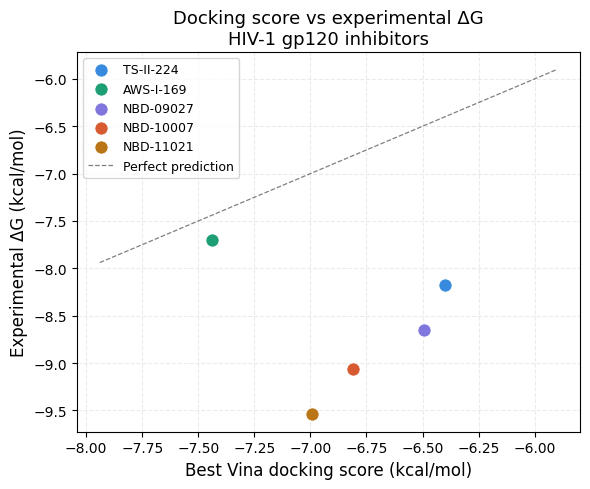


Scoring metrics (best score across all receptors):
  R²   = 0.039
  RMSE = 1.974 kcal/mol
  MAE  = 1.801 kcal/mol
  Slope = -0.114,  Intercept = -7.814


In [32]:
# @title Plot the lowest (best) docking score versus the experimental ΔG
# @markdown ΔG = RT · ln(IC50)   where RT = 0.592 kcal/mol

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

RT = 0.592  # kcal/mol

ligands        = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO',      '4DKR',      '4DKU',      '4DKV',      '4RZ8']

# ── Experimental IC50 values (geometric midpoint of your ranges, in µM) ──
# Converted to nM for the ΔG formula (IC50 × 1e-9 converts nM → M)
ic50_nM = {
    'TS-II-224':  1000.0,   # geometric mean of 0.5–2.0 µM  → 1.00 µM = 1000 nM
    'AWS-I-169':  2236.0,   # geometric mean of 1.0–5.0 µM  → 2.24 µM = 2236 nM
    'NBD-09027':   447.0,   # geometric mean of 0.2–1.0 µM  → 0.447 µM = 447 nM
    'NBD-10007':   224.0,   # geometric mean of 0.1–0.5 µM  → 0.224 µM = 224 nM
    'NBD-11021':   100.0,   # geometric mean of 0.05–0.2 µM → 0.10 µM = 100 nM
}

# Colors matching your project ligand palette
colors = {
    'TS-II-224':  '#378ADD',
    'AWS-I-169':  '#1D9E75',
    'NBD-09027':  '#7F77DD',
    'NBD-10007':  '#D85A30',
    'NBD-11021':  '#BA7517',
}

# ── Collect best (lowest) Vina score across all 5 receptors per ligand ────
best_scores = []   # one value per ligand — lowest score across all 25 runs
dG_values   = []   # one experimental ΔG per ligand

for ligand in ligands:

    all_scores = []
    for rec_code in receptor_codes:
        resultname = f'{rec_code}_{ligand}'
        csvfile    = SUMMARY_DIR / f'{resultname}.csv'

        result = pd.read_csv(csvfile)
        all_scores += result['score (kcal/mol)'].tolist()

    print(f'{ligand} — all scores: {all_scores}')
    best_scores.append(min(all_scores))

    # ΔG = RT · ln(IC50 in M)
    IC50_value = ic50_nM[ligand]
    dG_values.append(RT * np.log(IC50_value * 1e-9))

print('\nbest_scores:', best_scores)
print('dG_values:  ', dG_values)

# ── Plot: best docking score vs experimental ΔG ───────────────────
fig, ax = plt.subplots(figsize=(6, 5))

for i, ligand in enumerate(ligands):
    ax.scatter(
        best_scores[i], dG_values[i],
        label=ligand,
        color=colors[ligand],
        s=90, zorder=5, edgecolors='white', linewidths=0.6
    )

# Perfect-prediction diagonal
score_min = min(best_scores) - 0.5
score_max = max(best_scores) + 0.5
ax.plot([score_min, score_max], [score_min, score_max],
        'k--', linewidth=0.9, alpha=0.5, label='Perfect prediction')

ax.set_xlabel('Best Vina docking score (kcal/mol)', fontsize=12)
ax.set_ylabel('Experimental ΔG (kcal/mol)', fontsize=12)
ax.set_title('Docking score vs experimental ΔG\nHIV-1 gp120 inhibitors', fontsize=13)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.25, linestyle='--')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'dG_vs_score_plot.png', dpi=150)
plt.show()

# ── Scoring metrics ───────────────────────────────────────────────
from scipy import stats

exp  = np.array(dG_values)
pred = np.array(best_scores)

slope, intercept, r, p, se = stats.linregress(exp, pred)
R2   = r**2
RMSE = np.sqrt(np.mean((pred - exp)**2))
MAE  = np.mean(np.abs(pred - exp))

print(f'\nScoring metrics (best score across all receptors):')
print(f'  R²   = {R2:.3f}')
print(f'  RMSE = {RMSE:.3f} kcal/mol')
print(f'  MAE  = {MAE:.3f} kcal/mol')
print(f'  Slope = {slope:.3f},  Intercept = {intercept:.3f}')

In [35]:
ligand_list = [ligand.strip() for ligand in df['Ligand'].tolist()]
print("List of ligands:", ligand_list)

List of ligands: ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']


In [36]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Convert lists to numpy arrays and reshape for sklearn
X = np.array(best_scores).reshape(-1, 1)
y = np.array(dG_values)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y, X))
mae = mean_absolute_error(y, X)
r_squared = r2_score(y, X)

print(f"Root Mean Squared Error (RMSE): {rmse:.3f} kcal/mol")
print(f"Mean Absolute Error (MAE): {mae:.3f} kcal/mol")
print(f"Coefficient of Determination (R^2): {r_squared:.3f}")

Root Mean Squared Error (RMSE): 1.974 kcal/mol
Mean Absolute Error (MAE): 1.801 kcal/mol
Coefficient of Determination (R^2): -8.343


Self-docking score vs RMSD — linear regression metrics:
  R²          = 0.020
  Slope (m)   = -0.067  kcal/mol per Å
  Intercept   = -4.948 kcal/mol
  N poses     = 49  (5 ligands × 10 poses each)


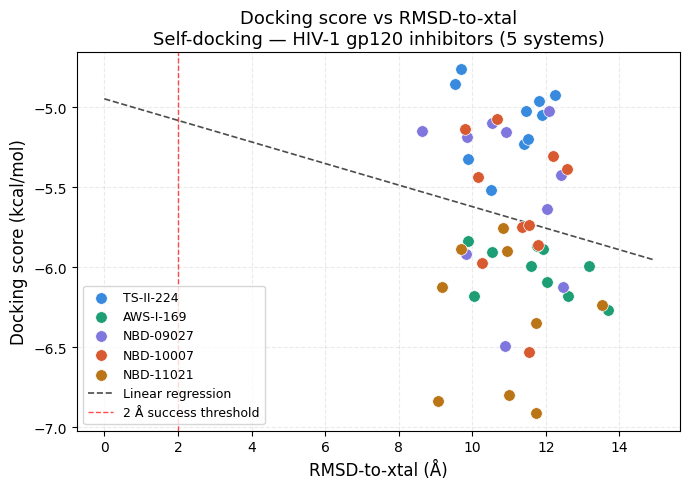

In [37]:
# @title Scatter plot: docking score vs RMSD-to-xtal (self-docking, all 5 systems)
#
# Uses only the SELF-docking CSV files (5 runs) where RMSD-to-xtal is meaningful.
# Cross-docking RMSDs are computed vs the native ligand of each receptor,
# so they are kept separate and not mixed into this self-docking plot.

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ── Self-docking pairs only (ligand docked into its own receptor) ──
self_docking_pairs = [
    ('TS-II-224', '4DKO'),
    ('AWS-I-169', '4DKR'),
    ('NBD-09027', '4DKU'),
    ('NBD-10007', '4DKV'),
    ('NBD-11021', '4RZ8'),
]

colors = {
    'TS-II-224':  '#378ADD',
    'AWS-I-169':  '#1D9E75',
    'NBD-09027':  '#7F77DD',
    'NBD-10007':  '#D85A30',
    'NBD-11021':  '#BA7517',
}

fig, ax = plt.subplots(figsize=(7, 5))

all_scores        = []
all_rmsd_to_xtals = []

for ligand, rec_code in self_docking_pairs:

    resultname = f'{rec_code}_{ligand}'
    csvfile    = SUMMARY_DIR / f'{resultname}.csv'

    result        = pd.read_csv(csvfile)
    scores        = result['score (kcal/mol)'].tolist()
    rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

    all_scores        += scores
    all_rmsd_to_xtals += rmsd_to_xtals

    ax.scatter(
        rmsd_to_xtals, scores,
        label=ligand,
        color=colors[ligand],
        s=70, zorder=5, edgecolors='white', linewidths=0.5
    )

# ── Linear regression across all 50 self-docking poses (5 ligands × 10 poses) ──
X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
y = np.array(all_scores)

model = LinearRegression()
model.fit(X, y)

rmsd_range = np.arange(0, 15, 0.1).reshape(-1, 1)
ax.plot(
    rmsd_range, model.predict(rmsd_range),
    'k--', linewidth=1.2, label='Linear regression', alpha=0.7
)

# ── RMSD = 2 Å success threshold line ─────────────────────────────
ax.axvline(x=2.0, color='red', linestyle='--', linewidth=1.0,
           alpha=0.7, label='2 Å success threshold')

# ── Metrics ───────────────────────────────────────────────────────
y_pred    = model.predict(X)
r_squared = r2_score(y, y_pred)

print(f'Self-docking score vs RMSD — linear regression metrics:')
print(f'  R²          = {r_squared:.3f}')
print(f'  Slope (m)   = {model.coef_[0]:.3f}  kcal/mol per Å')
print(f'  Intercept   = {model.intercept_:.3f} kcal/mol')
print(f'  N poses     = {len(all_scores)}  (5 ligands × 10 poses each)')

# ── Format plot ───────────────────────────────────────────────────
ax.set_xlabel('RMSD-to-xtal (Å)', fontsize=12)
ax.set_ylabel('Docking score (kcal/mol)', fontsize=12)
ax.set_title('Docking score vs RMSD-to-xtal\nSelf-docking — HIV-1 gp120 inhibitors (5 systems)', fontsize=13)
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'score_vs_rmsd_selfdocking.png', dpi=150)
plt.show()

Score vs RMSD — all 25 runs (self + cross-docking):
  R²        = 0.144
  Slope     = -0.023  kcal/mol per Å
  Intercept = -5.335 kcal/mol
  N poses   = 248  (25 runs × 10 poses)

Self-docking success rate (RMSD ≤ 2 Å):
  0 / 49 poses  (0.0%)


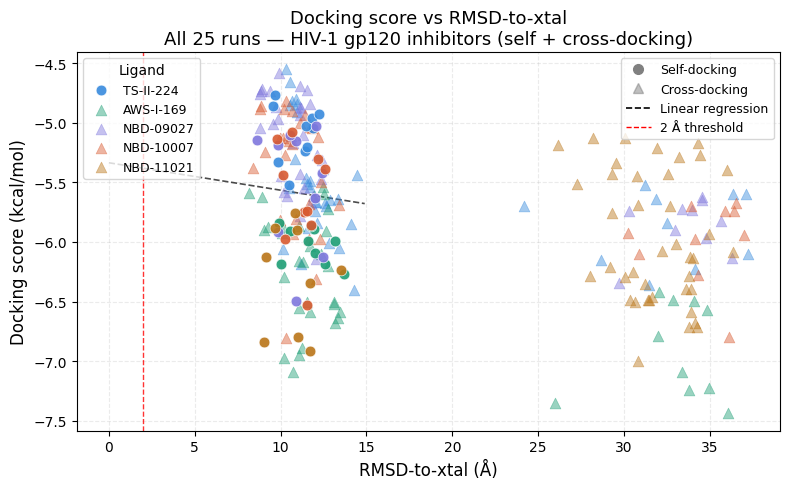

In [38]:
# @title Scatter plot: docking score vs RMSD-to-xtal — INCLUDES ALL 25 RUNS (self + cross-docking)
#
# All 5 ligands × 5 receptors = 25 runs × 10 poses = 250 poses total
# Self-docking poses plotted with filled markers, cross-docking with hollow markers

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

ligands        = ['TS-II-224', 'AWS-I-169', 'NBD-09027', 'NBD-10007', 'NBD-11021']
receptor_codes = ['4DKO',      '4DKR',      '4DKU',      '4DKV',      '4RZ8']

self_docking_pairs = {
    ('TS-II-224', '4DKO'),
    ('AWS-I-169', '4DKR'),
    ('NBD-09027', '4DKU'),
    ('NBD-10007', '4DKV'),
    ('NBD-11021', '4RZ8'),
}

colors = {
    'TS-II-224':  '#378ADD',
    'AWS-I-169':  '#1D9E75',
    'NBD-09027':  '#7F77DD',
    'NBD-10007':  '#D85A30',
    'NBD-11021':  '#BA7517',
}

fig, ax = plt.subplots(figsize=(8, 5))

all_scores        = []
all_rmsd_to_xtals = []
legend_handles    = {}   # one legend entry per ligand (avoid duplicates)

for ligand in ligands:
    for rec_code in receptor_codes:

        resultname = f'{rec_code}_{ligand}'
        csvfile    = SUMMARY_DIR / f'{resultname}.csv'

        result        = pd.read_csv(csvfile)
        scores        = result['score (kcal/mol)'].tolist()
        rmsd_to_xtals = result['RMSD-to-xtal (A)'].tolist()

        all_scores        += scores
        all_rmsd_to_xtals += rmsd_to_xtals

        is_self = (ligand, rec_code) in self_docking_pairs

        sc = ax.scatter(
            rmsd_to_xtals, scores,
            color   = colors[ligand],
            s       = 60,
            marker  = 'o' if is_self else '^',       # filled circle = self, triangle = cross
            alpha   = 0.9 if is_self else 0.45,      # self-docking more prominent
            edgecolors = 'white' if is_self else colors[ligand],
            linewidths = 0.5,
            zorder  = 5 if is_self else 3,
        )

        # One legend entry per ligand (first encounter)
        if ligand not in legend_handles:
            legend_handles[ligand] = sc

# ── Linear regression across all 250 poses ────────────────────────
X = np.array(all_rmsd_to_xtals).reshape(-1, 1)
y = np.array(all_scores)

model = LinearRegression()
model.fit(X, y)

rmsd_range = np.arange(0, 15, 0.1).reshape(-1, 1)
ax.plot(
    rmsd_range, model.predict(rmsd_range),
    'k--', linewidth=1.2, alpha=0.7, label='Linear regression'
)

# ── 2 Å RMSD success threshold ────────────────────────────────────
ax.axvline(x=2.0, color='red', linestyle='--', linewidth=1.0,
           alpha=0.8, label='2 Å success threshold')

# ── Metrics ───────────────────────────────────────────────────────
y_pred    = model.predict(X)
r_squared = r2_score(y, y_pred)

print('Score vs RMSD — all 25 runs (self + cross-docking):')
print(f'  R²        = {r_squared:.3f}')
print(f'  Slope     = {model.coef_[0]:.3f}  kcal/mol per Å')
print(f'  Intercept = {model.intercept_:.3f} kcal/mol')
print(f'  N poses   = {len(all_scores)}  (25 runs × 10 poses)')

# Count success rate (RMSD ≤ 2 Å) for self-docking only
self_rmsds = [
    rmsd for ligand in ligands for rec_code in receptor_codes
    if (ligand, rec_code) in self_docking_pairs
    for rmsd in pd.read_csv(SUMMARY_DIR / f'{rec_code}_{ligand}.csv')['RMSD-to-xtal (A)'].tolist()
]
success = sum(1 for r in self_rmsds if r <= 2.0)
print(f'\nSelf-docking success rate (RMSD ≤ 2 Å):')
print(f'  {success} / {len(self_rmsds)} poses  ({100*success/len(self_rmsds):.1f}%)')

# ── Legend ────────────────────────────────────────────────────────
ligand_legend = ax.legend(
    handles=list(legend_handles.values()),
    labels=list(legend_handles.keys()),
    loc='upper left', fontsize=9, title='Ligand'
)
ax.add_artist(ligand_legend)

# Marker legend (self vs cross)
from matplotlib.lines import Line2D
marker_legend_handles = [
    Line2D([0],[0], marker='o', color='gray', linestyle='None', markersize=7, label='Self-docking'),
    Line2D([0],[0], marker='^', color='gray', linestyle='None', markersize=7, alpha=0.5, label='Cross-docking'),
    Line2D([0],[0], color='k',   linestyle='--', linewidth=1.2, label='Linear regression'),
    Line2D([0],[0], color='red', linestyle='--', linewidth=1.0, label='2 Å threshold'),
]
ax.legend(handles=marker_legend_handles, loc='upper right', fontsize=9)

ax.set_xlabel('RMSD-to-xtal (Å)', fontsize=12)
ax.set_ylabel('Docking score (kcal/mol)', fontsize=12)
ax.set_title('Docking score vs RMSD-to-xtal\nAll 25 runs — HIV-1 gp120 inhibitors (self + cross-docking)', fontsize=13)
ax.grid(True, alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'score_vs_rmsd_all_runs.png', dpi=150)
plt.show()